In [ ]:
!pip install pytrends

# **MISSING VALUES**

In [ ]:
import pandas as pd
from Feature_Engineer import GameFeatureEngineering
from Graph_Visualize import Visualize_Data
import matplotlib.pyplot as plt
from Encoder import Encoder
from Scalar import Scaler
df = pd.read_csv("advanced_games_dataset.csv")
feature_Engineering = GameFeatureEngineering(df)
df = feature_Engineering.build_features()
df.info()
missing_Values = df.isnull().sum()
print("MISSING VALUES ARE")
print(missing_Values)
missing_Values_Percentage = (df.isnull().sum() / len(df)) * 100
print("MISSING VALUES PERCENTAGE ARE: ")
print(missing_Values_Percentage)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26675 entries, 0 to 26674
Data columns (total 24 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   date                     26675 non-null  object  
 1   avg_players              26675 non-null  float64 
 2   peak_players             26675 non-null  float64 
 3   players_change_pct       26675 non-null  float64 
 4   rolling_7d_avg_players   26525 non-null  float64 
 5   rolling_30d_avg_players  25950 non-null  float64 
 6   google_trend             26675 non-null  int64   
 7   game                     26675 non-null  object  
 8   appid                    26675 non-null  int64   
 9   price                    26675 non-null  float64 
 10  discount_percent         26675 non-null  int64   
 11  initial_price            26675 non-null  float64 
 12  is_free                  26675 non-null  int64   
 13  total_reviews            26675 non-null  int64   
 14  positi

In [ ]:
df.isnull().sum()[df.isnull().sum() > 0]

,0
rolling_7d_avg_players,150
rolling_30d_avg_players,725
player_momentum,29


In [ ]:
df["player_momentum"] = df["player_momentum"].fillna(df["player_momentum"].mean())
df.isnull().sum()[df.isnull().sum() > 0]

,0
rolling_7d_avg_players,150
rolling_30d_avg_players,725


# **Ouliers Handling**


In [ ]:
numeric_Col = ["avg_players",  "peak_players" , "google_trend" , "price" , "initial_price" , "engagement_ratio" , "community_sentiment" , "player_momentum" , "popularity_score"]
for col in numeric_Col:
  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)
  IQR = Q3 - Q1
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR
  df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]
  df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 23198 entries, 2188 to 26674
Data columns (total 24 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   date                     23198 non-null  object  
 1   avg_players              23198 non-null  float64 
 2   peak_players             23198 non-null  float64 
 3   players_change_pct       23198 non-null  float64 
 4   rolling_7d_avg_players   23072 non-null  float64 
 5   rolling_30d_avg_players  22589 non-null  float64 
 6   google_trend             23198 non-null  int64   
 7   game                     23198 non-null  object  
 8   appid                    23198 non-null  int64   
 9   price                    23198 non-null  float64 
 10  discount_percent         23198 non-null  int64   
 11  initial_price            23198 non-null  float64 
 12  is_free                  23198 non-null  int64   
 13  total_reviews            23198 non-null  int64   
 14  positive

In [ ]:
encoding_Data = Encoder()
df = encoding_Data.label_encode(df , ["popularity_level"])
print(df['popularity_level'].value_counts())
print(df['popularity_level'].value_counts(normalize=True) * 100)


NameError: name 'Encoder' is not defined

In [ ]:
bool_Cols = ["best_game_over_time" , "need_discount" , "is_free"]
df[bool_Cols] = df[bool_Cols].astype(int)
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
Index: 16953 entries, 4268 to 26674
Data columns (total 24 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   date                     16953 non-null  object 
 1   avg_players              16953 non-null  float64
 2   peak_players             16953 non-null  float64
 3   players_change_pct       16953 non-null  float64
 4   rolling_7d_avg_players   16891 non-null  float64
 5   rolling_30d_avg_players  16677 non-null  float64
 6   google_trend             16953 non-null  int64  
 7   game                     16953 non-null  object 
 8   appid                    16953 non-null  int64  
 9   price                    16953 non-null  float64
 10  discount_percent         16953 non-null  int64  
 11  initial_price            16953 non-null  float64
 12  is_free                  16953 non-null  int64  
 13  total_reviews            16953 non-null  int64  
 14  positive_reviews_est    

,date,avg_players,peak_players,players_change_pct,rolling_7d_avg_players,rolling_30d_avg_players,google_trend,game,appid,price,...,positive_reviews_est,negative_reviews_est,data_collected_at,popularity_score,popularity_level,best_game_over_time,need_discount,engagement_ratio,community_sentiment,player_momentum
4268,4/1/2023,90736.77000,157231.0000,0.000000,NaN,NaN,0,Grand Theft Auto V,271590,0.0,...,1587845,280207,47:11.7,0.115507,0,0,0,1.732826,0.85,201.184286
4269,4/2/2023,90688.87867,157085.3667,-0.000528,NaN,NaN,7,Grand Theft Auto V,271590,0.0,...,1587845,280207,47:11.7,0.136485,0,0,1,1.732135,0.85,397.123331
4270,4/3/2023,90640.98733,156939.7333,-0.000528,NaN,NaN,7,Grand Theft Auto V,271590,0.0,...,1587845,280207,47:11.7,0.136464,0,0,1,1.731443,0.85,587.817133
4271,4/4/2023,90593.09600,156794.1000,-0.000528,NaN,NaN,7,Grand Theft Auto V,271590,0.0,...,1587845,280207,47:11.7,0.136443,0,0,1,1.730751,0.85,773.265695
4272,4/5/2023,90545.20467,156648.4667,-0.000529,NaN,NaN,7,Grand Theft Auto V,271590,0.0,...,1587845,280207,47:11.7,0.136421,0,0,1,1.730058,0.85,953.469016


In [ ]:
df = df.drop(columns=["date" , "data_collected_at" , "appid"])

In [ ]:
df.head()

,avg_players,peak_players,players_change_pct,rolling_7d_avg_players,rolling_30d_avg_players,google_trend,game,price,discount_percent,initial_price,...,total_reviews,positive_reviews_est,negative_reviews_est,popularity_score,popularity_level,best_game_over_time,need_discount,engagement_ratio,community_sentiment,player_momentum
4268,90736.77000,157231.0000,0.000000,NaN,NaN,0,Grand Theft Auto V,0.0,0,0.0,...,1868053,1587845,280207,0.115507,0,0,0,1.732826,0.85,201.184286
4269,90688.87867,157085.3667,-0.000528,NaN,NaN,7,Grand Theft Auto V,0.0,0,0.0,...,1868053,1587845,280207,0.136485,0,0,1,1.732135,0.85,397.123331
4270,90640.98733,156939.7333,-0.000528,NaN,NaN,7,Grand Theft Auto V,0.0,0,0.0,...,1868053,1587845,280207,0.136464,0,0,1,1.731443,0.85,587.817133
4271,90593.09600,156794.1000,-0.000528,NaN,NaN,7,Grand Theft Auto V,0.0,0,0.0,...,1868053,1587845,280207,0.136443,0,0,1,1.730751,0.85,773.265695
4272,90545.20467,156648.4667,-0.000529,NaN,NaN,7,Grand Theft Auto V,0.0,0,0.0,...,1868053,1587845,280207,0.136421,0,0,1,1.730058,0.85,953.469016


In [ ]:
test_data = ["low" , "medium" , "high"]

In [ ]:
from sklearn.preprocessing import LabelEncoder
test_data = ["low" , "medium" , "high"]
# Initialize the LabelEncoder
label_encoder = LabelEncoder()
# Fit and transform the test_data
encoded_data = label_encoder.fit_transform(test_data)
print("Original Data:", test_data)
print("Encoded Data:", encoded_data)
print("Mapping:", label_encoder.classes_)

Original Data: ['low', 'medium', 'high']
Encoded Data: [1 2 0]
Mapping: ['high' 'low' 'medium']


In [ ]:
import pandas as pd

# Define the semantic mapping
semantic_mapping = {'low': 0, 'medium': 1, 'high': 2}

# Convert test_data to a pandas Series to use map
# Using the previously defined test_data
semantically_encoded_data = pd.Series(test_data).map(semantic_mapping).values

print("Original Data:", test_data)
print("Semantically Encoded Data:", semantically_encoded_data)
print("Semantic Mapping:", semantic_mapping)

Original Data: ['low', 'medium', 'high']
Semantically Encoded Data: [0 1 2]
Semantic Mapping: {'low': 0, 'medium': 1, 'high': 2}


# **Visualize_Data**

In [ ]:
vis_Data = Visualize_Data(df)
vis_Data.yearly_trend("date", "avg_players")




KeyError: 'date'

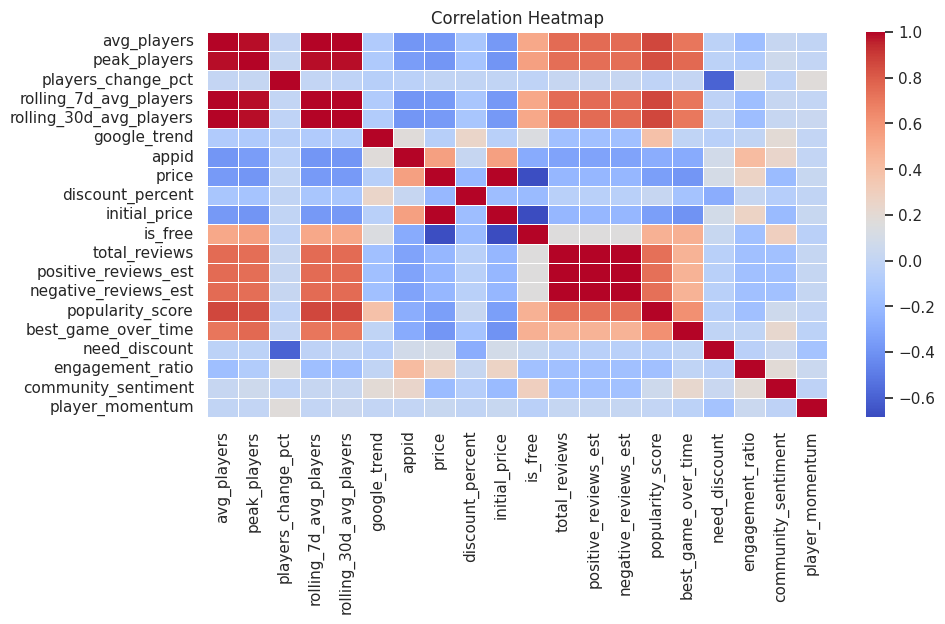

In [ ]:
vis_Data.heatmap_corr()

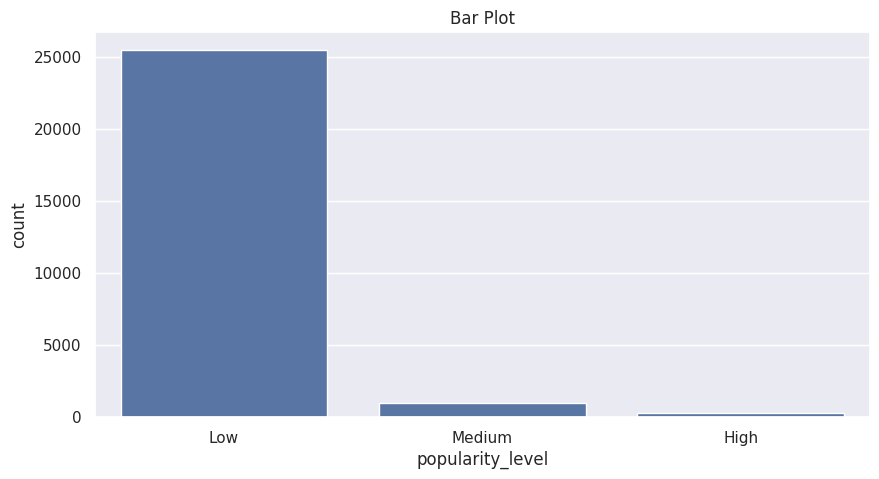

In [ ]:
vis_Data.bar_plot("popularity_level")

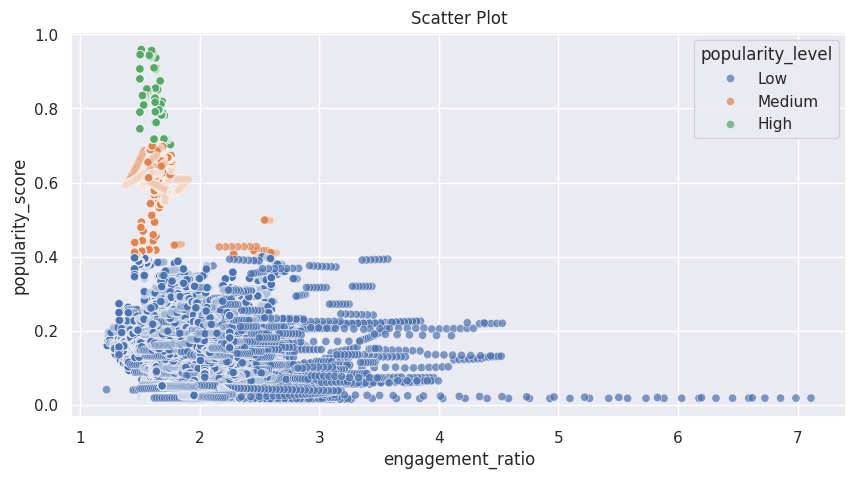

In [ ]:
vis_Data.scatter_plot(
    x="engagement_ratio",
    y="popularity_score",
    hue="popularity_level"
)

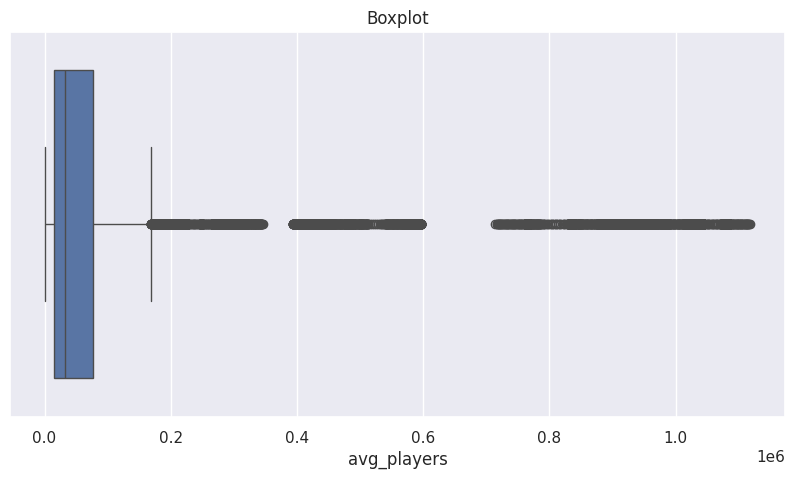

In [ ]:
vis_Data.boxplot("avg_players")

In [ ]:
df = df.drop(columns=['game'])
df['rolling_7d_avg_players'] = df['rolling_7d_avg_players'].fillna(df['rolling_7d_avg_players'].mean())
df['rolling_30d_avg_players'] = df['rolling_30d_avg_players'].fillna(df['rolling_30d_avg_players'].mean())
df.info()
print("\nRemaining missing values after imputation:")
print(df.isnull().sum()[df.isnull().sum() > 0])

# **ABOVE WORK WAS DOING MANUALLY. NOW FINAL SUBMISSION IS DONE THROUGH THE GIT**


*   Colab Public Link: https://colab.research.google.com/drive/1-2TCFzLPUqAOSbgygn233nSAEwdxuNil?usp=sharing

*   Public Repo Link: https://github.com/taimoor0078/Programming-20054191-



# **Step 1: Cloning the Data from the GIT Repo**

In [ ]:
!git clone https://github.com/taimoor0078/Programming-20054191-
%cd Programming-20054191-

Cloning into 'Programming-20054191-'...
remote: Enumerating objects: 136, done.
remote: Counting objects: 100% (136/136), done.
remote: Compressing objects: 100% (103/103), done.
remote: Total 136 (delta 77), reused 61 (delta 30), pack-reused 0 (from 0)
Receiving objects: 100% (136/136), 4.87 MiB | 4.29 MiB/s, done.
Resolving deltas: 100% (77/77), done.
/content/Programming-20054191-


# 1.1: Now Checking the files in my GIT Repo

In [ ]:
!ls

 advanced_games_dataset.csv   Feature_Engineer.py   requirements.txt
 DataAcquisition.py	     'Final File.py'	    Scalar.py
 Database_Class.py	      Graph_Visualize.py
 Encoder.py		      README.md


In the above output, there are multiple files as given below
*   advanced_games_dataset.csv (THE ACTUAL DATASET GATHERING FROM STEAM API, STEAM CHARTS AND GOOGLE TRENDS)
*   Feature_Engineer.py
*   DataAcquisition.py
*   Final File.py
*   Scalar.py
*   Database_Class.py	   
*   Graph_Visualize.py
*   Encoder.py
*   README.md
*   requirements.txt









     
	    

   

	      




# **Step 2: Cloning the advanced_games_dataset.csv from the GIT Repo named 'Programming-20054191-'**




In [ ]:
import sys
import pandas as pd
import numpy as np
from Graph_Visualize import Visualize_Data
from Feature_Engineer import GameFeatureEngineering
from Encoder import Encoder
from Scalar import Scaler
from Database_Class import GameDatabase

sys.path.append('/content/Programming-20054191-')
games_DF = pd.read_csv('advanced_games_dataset.csv')
vis_GameDataset = Visualize_Data(games_DF)
feature_GameDataset = GameFeatureEngineering(games_DF)
encode_GameDataset = Encoder()
scale_GameDataset = Scaler()
games_DF.info()
games_DF.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25900 entries, 0 to 25899
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   date              25900 non-null  object 
 1   avg_players       25900 non-null  float64
 2   peak_players      25900 non-null  float64
 3   game              25900 non-null  object 
 4   appid             25900 non-null  int64  
 5   google_trend      25900 non-null  float64
 6   price             25900 non-null  float64
 7   discount          25900 non-null  int64  
 8   initial_price     25900 non-null  float64
 9   total_reviews     25900 non-null  int64  
 10  positive_reviews  25900 non-null  int64  
 11  negative_reviews  25900 non-null  int64  
 12  is_free           25900 non-null  int64  
dtypes: float64(5), int64(6), object(2)
memory usage: 2.6+ MB


(25900, 13)

In the current Dataset, there are multiple columns with their datatypes and sources as given below:
**Acquire Data from the Steam Charts as Webscraping using BeautifulSoap**
*   Date
*   avg_players         (float)
*   peak_player         (float)

**Acquire Data from the Steam Api**.
Public Link of Api: https://store.steampowered.com/api/appdetails?appids={appid}&cc=us
*   game                (string)
*   appid               (integter) 	   
*   price               (float)
*   disount             (integter)
*   initial_price       (float)
*   total_reviews       (integer)
*   postive_reviews     (integer)
*   negative_reviews    (integer)
*   is_free             (integer)

**Acquire Data from the Google Trends**
*   google_trend        (float)




# **Step 3: Data Cleaning:**
*   Check and Processing the Missing Values
*   Check the Duplicates in the Dataset
*   Outliers and Processing the Missing Values



In [ ]:
missing_Values = games_DF.isnull().sum()
if (missing_Values > 0).any():
  missing_values_Percentage = (games_DF.isnull().sum() / len(games_DF)) * 100
  print("Missing Values Percentage are: ")
  print(missing_values_Percentage)
else:
  print("Missing Values are: " , missing_Values)
  print("There is no Missing Value in the Game Dataset")

Missing Values are:  date                0
avg_players         0
peak_players        0
game                0
appid               0
google_trend        0
price               0
discount            0
initial_price       0
total_reviews       0
positive_reviews    0
negative_reviews    0
is_free             0
dtype: int64
There is no Missing Value in the Game Dataset


*In the above output, there is no missing value in the current raw dataset.*

### **Checking the Duplicate Values in the Dataset**



In [ ]:
duplicate_Count = games_DF.duplicated().sum()
if duplicate_Count > 0:
  duplicate_Rows = games_DF[games_DF.duplicated()]
  print("Duplicate Rows are: ")
  print(duplicate_Rows)
else:
  print("Duplicate Value: " , duplicate_Count)
  print("There is no Duplicate Value in the Game Dataset")


Duplicate Value:  0
There is no Duplicate Value in the Game Dataset


In the above output, there is no Duplicate Value in the Dataset

### **Checking the Outliers in the Dataset**
I learn from one sources by searching google search what are the types of outliers. There I studies Skewed Values.
On GPT I studies it in Detailed. Here the Link Below of that conversation
https://chatgpt.com/share/69d37f56-b6d4-8333-859c-8fdd72711e5e



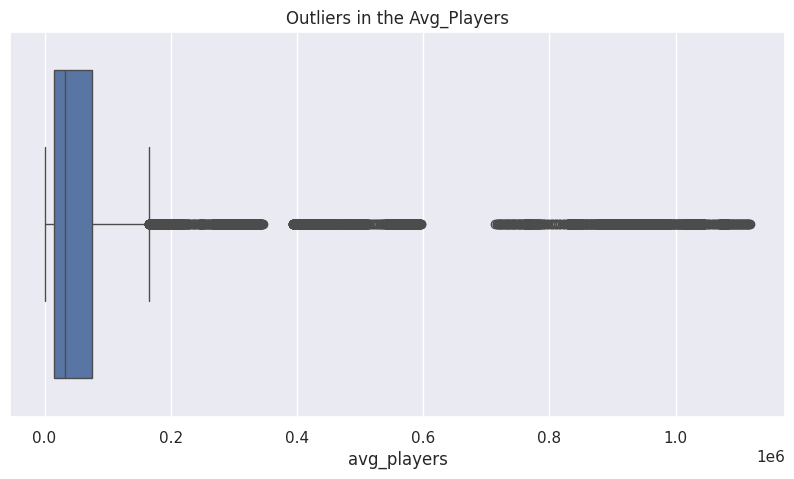

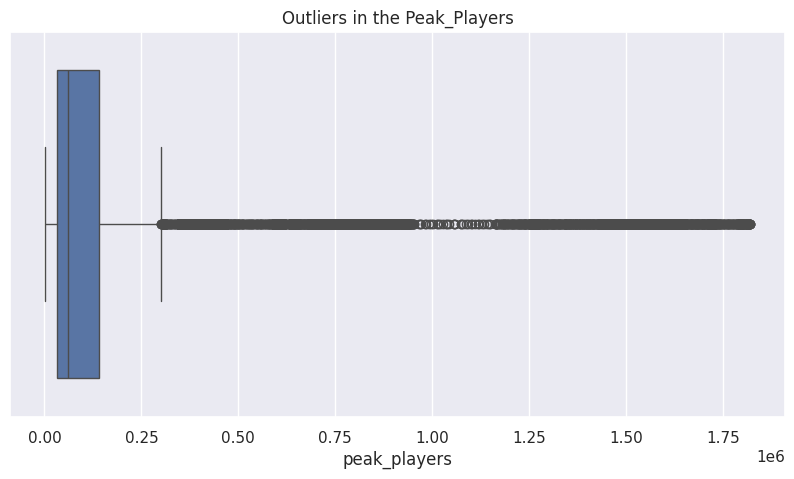

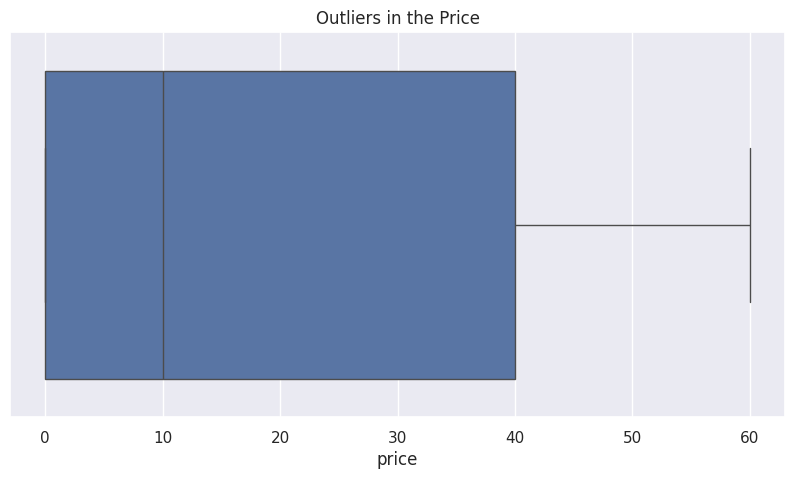

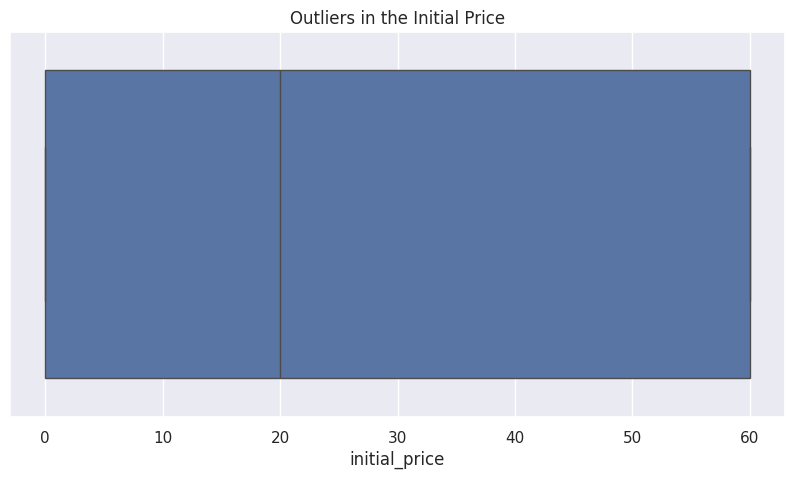

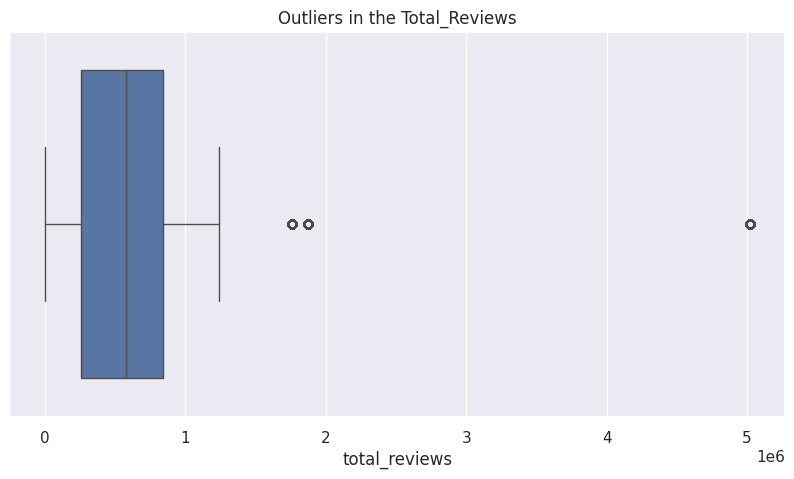

In [ ]:
vis_GameDataset.boxplot("avg_players" , "Outliers in the Avg_Players")
vis_GameDataset.boxplot("peak_players" , "Outliers in the Peak_Players")
vis_GameDataset.boxplot("price" , "Outliers in the Price")
vis_GameDataset.boxplot("initial_price" , "Outliers in the Initial Price")
vis_GameDataset.boxplot("total_reviews" , "Outliers in the Total_Reviews")

In [ ]:
# Check Outliers
numeric_Columns = games_DF.select_dtypes(include = ['float64' , 'int64']).columns
for int_column in numeric_Columns:
  qunatile_1 = games_DF[int_column].quantile(0.25)
  quantile_3 = games_DF[int_column].quantile(0.75)
  calculated_IQR = quantile_3 - qunatile_1
  lower_Bound = qunatile_1 - (1.5 * calculated_IQR)
  upper_Bound = quantile_3 + (1.5 * calculated_IQR)
  gamesDS_outliers = games_DF[(games_DF[int_column]< lower_Bound) | (games_DF[int_column] > upper_Bound)]
  print(int_column , ":" , len(gamesDS_outliers) , "Outliers")


avg_players : 3422 Outliers
peak_players : 3603 Outliers
appid : 0 Outliers
google_trend : 3488 Outliers
price : 0 Outliers
discount : 4144 Outliers
initial_price : 0 Outliers
total_reviews : 3108 Outliers
positive_reviews : 3108 Outliers
negative_reviews : 3108 Outliers
is_free : 0 Outliers


In the above results, multiple variables show Outliers as given below
*   avg_players : 3422 Outliers
*   peak_players : 3603 Outliers
*   appid : 0 Outliers
*   google_trend : 3484 Outliers
*   price : 0 Outliers
*   discount : 3108 Outliers
*   initial_price : 0 Outliers
*   total_reviews : 3108 Outliers
*   positive_reviews : 3108 Outliers
*   negative_reviews : 3108 Outliers
*   is_free : 0 Outliers

In this result, **Outliers were detected using the IQR method**, which identifies values outside the normal range. Since **the data is highly skewed**, **log transformation** will be to reduce **the impact of extreme values** and normalize the distribution. **Google Trend and Discount will not be transformed** because they are **bounded and discrete variables** respectively, where extreme values are valid. **Z-score** was not applied because **it assumes normal distribution, whereas the data is skewed.**











In [ ]:
transform_Columns = ["avg_players" , "peak_players" , "total_reviews" , "positive_reviews" , "negative_reviews"]
for transformation in transform_Columns:
  games_DF[transformation] = np.log1p(games_DF[transformation])

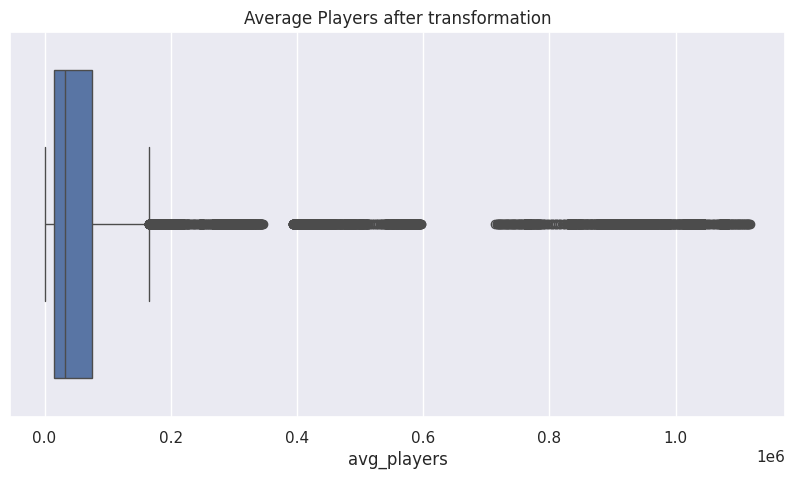

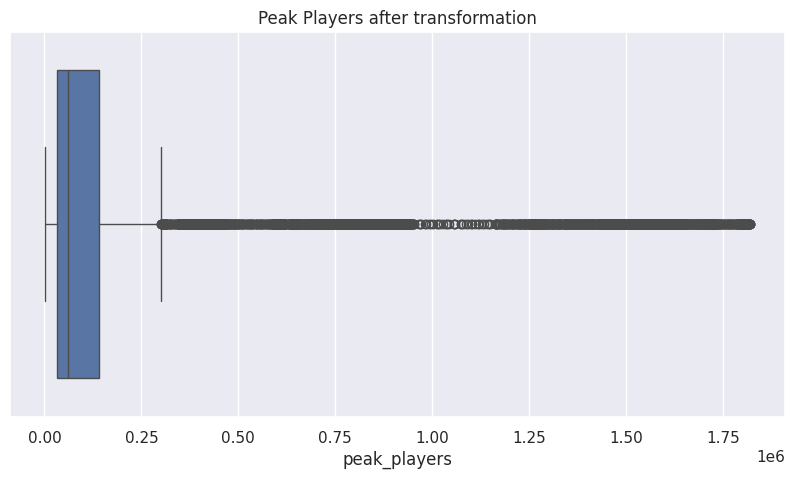

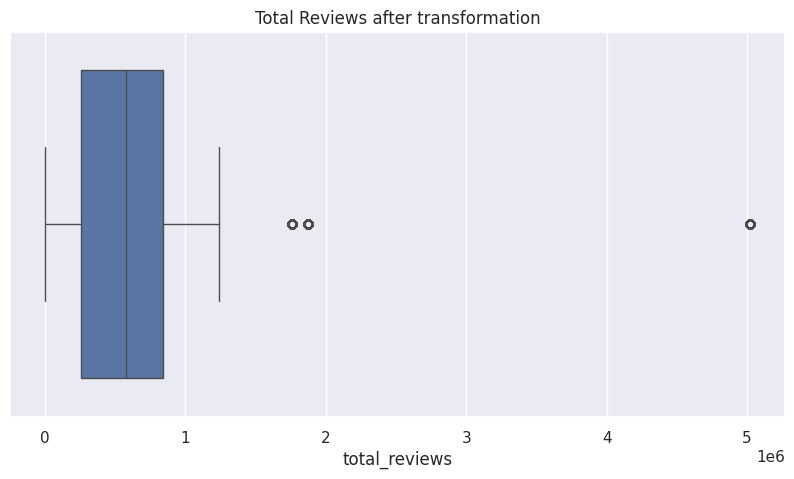

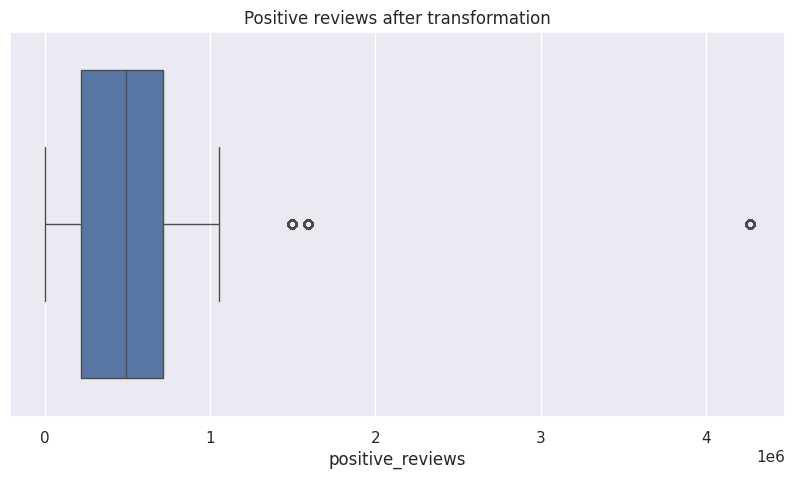

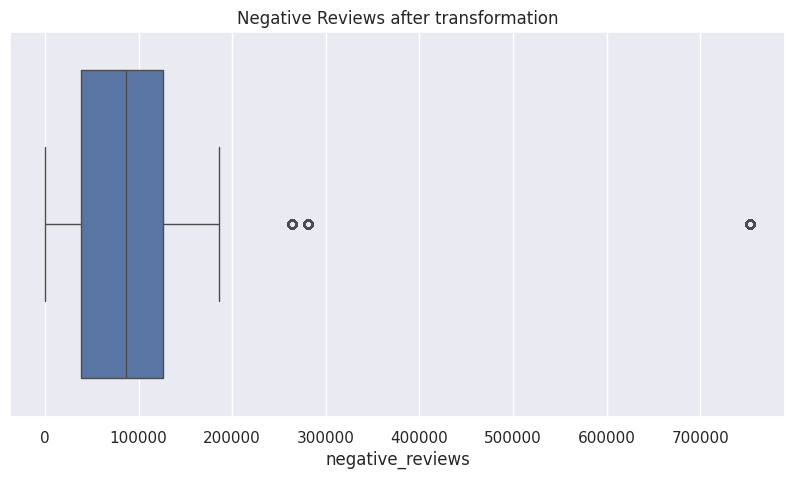

In [ ]:
vis_GameDataset.boxplot("avg_players" , "Average Players after transformation")
vis_GameDataset.boxplot("peak_players" , "Peak Players after transformation")
vis_GameDataset.boxplot("total_reviews" , "Total Reviews after transformation")
vis_GameDataset.boxplot("positive_reviews" , "Positive reviews after transformation")
vis_GameDataset.boxplot("negative_reviews" , "Negative Reviews after transformation")


In [ ]:
# Check Outliers again I copied last code from the above cells
numeric_Columns = games_DF.select_dtypes(include = ['float64' , 'int64']).columns
for int_column in numeric_Columns:
  qunatile_1 = games_DF[int_column].quantile(0.25)
  quantile_3 = games_DF[int_column].quantile(0.75)
  calculated_IQR = quantile_3 - qunatile_1
  lower_Bound = qunatile_1 - (1.5 * calculated_IQR)
  upper_Bound = quantile_3 + (1.5 * calculated_IQR)
  gamesDS_outliers = games_DF[(games_DF[int_column]< lower_Bound) | (games_DF[int_column] > upper_Bound)]
  print(int_column , ":" , len(gamesDS_outliers) , "Outliers")


avg_players : 854 Outliers
peak_players : 1020 Outliers
appid : 0 Outliers
google_trend : 3488 Outliers
price : 0 Outliers
discount : 4144 Outliers
initial_price : 0 Outliers
total_reviews : 4144 Outliers
positive_reviews : 4144 Outliers
negative_reviews : 4144 Outliers
is_free : 0 Outliers


In [ ]:
# Capping the outliers now to reach them at the Zero
numeric_Columns = ["avg_players" , "peak_players" , "total_reviews" , "positive_reviews" , "negative_reviews"]
for int_column in numeric_Columns:
  qunatile_1 = games_DF[int_column].quantile(0.25)
  quantile_3 = games_DF[int_column].quantile(0.75)
  calculated_IQR = quantile_3 - qunatile_1
  lower_Bound = qunatile_1 - (1.5 * calculated_IQR)
  upper_Bound = quantile_3 + (1.5 * calculated_IQR)
  games_DF[int_column] = np.where(games_DF[int_column] < lower_Bound , lower_Bound , games_DF[int_column])
  games_DF[int_column] = np.where(games_DF[int_column] > upper_Bound , upper_Bound , games_DF[int_column])


In [ ]:
# Check Outliers again I copied last code from the above cells
numeric_Columns = games_DF.select_dtypes(include = ['float64' , 'int64']).columns
for int_column in numeric_Columns:
  qunatile_1 = games_DF[int_column].quantile(0.25)
  quantile_3 = games_DF[int_column].quantile(0.75)
  calculated_IQR = quantile_3 - qunatile_1
  lower_Bound = qunatile_1 - (1.5 * calculated_IQR)
  upper_Bound = quantile_3 + (1.5 * calculated_IQR)
  gamesDS_outliers = games_DF[(games_DF[int_column]< lower_Bound) | (games_DF[int_column] > upper_Bound)]
  print(int_column , ":" , len(gamesDS_outliers) , "Outliers")

avg_players : 0 Outliers
peak_players : 0 Outliers
appid : 0 Outliers
google_trend : 3488 Outliers
price : 0 Outliers
discount : 4144 Outliers
initial_price : 0 Outliers
total_reviews : 0 Outliers
positive_reviews : 0 Outliers
negative_reviews : 0 Outliers
is_free : 0 Outliers


In [ ]:
games_DF.shape

(25900, 13)

# **Step 4: FEATURE ENGINEERING**


In [ ]:
final_Dataset = feature_GameDataset.build_features()
final_Dataset.info()
final_Dataset.shape

<class 'pandas.core.frame.DataFrame'>
Index: 25900 entries, 0 to 25899
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   date                 25900 non-null  datetime64[ns]
 1   avg_players          25900 non-null  float64       
 2   peak_players         25900 non-null  float64       
 3   game                 25900 non-null  object        
 4   appid                25900 non-null  int64         
 5   google_trend         25900 non-null  float64       
 6   price                25900 non-null  float64       
 7   discount             25900 non-null  int64         
 8   initial_price        25900 non-null  float64       
 9   total_reviews        25900 non-null  int64         
 10  positive_reviews     25900 non-null  int64         
 11  negative_reviews     25900 non-null  int64         
 12  is_free              25900 non-null  int64         
 13  popularity_score     25900 non-null 

(25900, 20)

# In the above output, it is clear that new features has been added in the dataset data. At the next step, there is a need to evaluate the missing values and duplicates in the dataset.

In [ ]:
missing_Values = final_Dataset.isnull().sum()
if missing_Values.any():
  missing_Values_Percentage = (final_Dataset.isnull().sum() / len(final_Dataset)) * 100
else:
  print("There are no Missing Values in the Final Game Dataset: ")
  print(missing_Values)

There are no Missing Values in the Final Game Dataset: 
date                   0
avg_players            0
peak_players           0
game                   0
appid                  0
google_trend           0
price                  0
discount               0
initial_price          0
total_reviews          0
positive_reviews       0
negative_reviews       0
is_free                0
popularity_score       0
popularity_level       0
best_game_over_time    0
need_discount          0
engagement_ratio       0
community_sentiment    0
player_momentum        0
dtype: int64


In [ ]:
duplicate_Count = final_Dataset.duplicated().sum()
if duplicate_Count > 0:
  duplicate_Rows = final_Dataset[final_Dataset.duplicated()]
  print("Duplicate Rows are: ")
  print(duplicate_Rows)
else:
  print("Duplicate Value: " , duplicate_Count)
  print("There is no Duplicate Value in the Final Game Dataset")


Duplicate Value:  0
There is no Duplicate Value in the Final Game Dataset


Checking the values of Category and Boolean


In [ ]:
for columns in final_Dataset.select_dtypes(include=['category' , 'bool']):
  print(f"{columns}: {final_Dataset[columns].unique()}")

popularity_level: ['High', 'Low', 'Medium']
Categories (3, object): ['Low' < 'Medium' < 'High']
best_game_over_time: [ True False]
need_discount: [False  True]


# **Step 5: Data Preprocessing**

Correct the format of Date Column


In [ ]:
final_Dataset['date'] = pd.to_datetime(final_Dataset['date'] , errors = 'coerce')
final_Dataset.isnull().sum()
final_Dataset

,date,avg_players,peak_players,game,appid,google_trend,price,discount,initial_price,total_reviews,positive_reviews,negative_reviews,is_free,popularity_score,popularity_level,best_game_over_time,need_discount,engagement_ratio,community_sentiment,player_momentum
0,2023-05-01,1117517.40,1802853.0,Counter-Strike 2,730,0.0,0.00,0,0.00,5018775,4265958,752816,1,0.700000,High,True,False,1.613266,0,0.000000
4144,2023-05-01,89300.03,152862.0,Grand Theft Auto V,271590,0.0,0.00,0,0.00,1872977,1592030,280946,0,0.114111,High,False,False,1.711780,0,0.000000
18648,2023-05-01,7820.83,18899.0,Battlefield 2042,1517290,0.0,59.99,0,59.99,258252,219514,38737,0,0.013252,Low,False,False,2.416495,0,0.000000
21756,2023-05-01,9598.20,20689.0,Forza Horizon 5,1551360,0.0,59.99,0,59.99,247505,210379,37125,0,0.013620,Low,False,False,2.155508,0,0.000000
7252,2023-05-01,78633.18,192081.0,Destiny 2,1085660,0.0,0.00,0,0.00,133804,113733,20070,1,0.040005,Medium,False,False,2.442747,0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10359,2026-03-01,52427.32,98923.0,Warframe,230410,45.0,0.00,0,0.00,2880,2448,432,1,0.158050,High,False,True,1.886860,0,-65220.171905
24863,2026-03-01,46223.03,84502.0,Dead by Daylight,381210,61.0,19.99,0,19.99,651105,553439,97665,0,0.229111,High,False,True,1.828136,0,-58868.262298
8287,2026-03-01,7292.55,14030.0,Destiny 2,1085660,51.0,0.00,0,0.00,133804,113733,20070,1,0.161055,High,False,True,1.923881,0,-57255.547560
6215,2026-03-01,106569.94,200309.0,Rust,252490,87.0,39.99,0,39.99,1123212,954730,168481,0,0.352957,High,True,True,1.879601,0,-48713.909893


Extract Year and month from final_Dataset['date']

In [ ]:
if 'date' in final_Dataset.columns:
  final_Dataset['year'] = final_Dataset['date'].dt.year
  final_Dataset['month'] = final_Dataset['date'].dt.month
final_Dataset

,date,avg_players,peak_players,game,appid,google_trend,price,discount,initial_price,total_reviews,...,is_free,popularity_score,popularity_level,best_game_over_time,need_discount,engagement_ratio,community_sentiment,player_momentum,year,month
0,2023-05-01,1117517.40,1802853.0,Counter-Strike 2,730,0.0,0.00,0,0.00,5018775,...,1,0.700000,High,True,False,1.613266,0,0.000000,2023,5
4144,2023-05-01,89300.03,152862.0,Grand Theft Auto V,271590,0.0,0.00,0,0.00,1872977,...,0,0.114111,High,False,False,1.711780,0,0.000000,2023,5
18648,2023-05-01,7820.83,18899.0,Battlefield 2042,1517290,0.0,59.99,0,59.99,258252,...,0,0.013252,Low,False,False,2.416495,0,0.000000,2023,5
21756,2023-05-01,9598.20,20689.0,Forza Horizon 5,1551360,0.0,59.99,0,59.99,247505,...,0,0.013620,Low,False,False,2.155508,0,0.000000,2023,5
7252,2023-05-01,78633.18,192081.0,Destiny 2,1085660,0.0,0.00,0,0.00,133804,...,1,0.040005,Medium,False,False,2.442747,0,0.000000,2023,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10359,2026-03-01,52427.32,98923.0,Warframe,230410,45.0,0.00,0,0.00,2880,...,1,0.158050,High,False,True,1.886860,0,-65220.171905,2026,3
24863,2026-03-01,46223.03,84502.0,Dead by Daylight,381210,61.0,19.99,0,19.99,651105,...,0,0.229111,High,False,True,1.828136,0,-58868.262298,2026,3
8287,2026-03-01,7292.55,14030.0,Destiny 2,1085660,51.0,0.00,0,0.00,133804,...,1,0.161055,High,False,True,1.923881,0,-57255.547560,2026,3
6215,2026-03-01,106569.94,200309.0,Rust,252490,87.0,39.99,0,39.99,1123212,...,0,0.352957,High,True,True,1.879601,0,-48713.909893,2026,3


In [ ]:
final_Dataset['encoded_popularity_level'] = final_Dataset['popularity_level'].cat.codes
final_Dataset

,date,avg_players,peak_players,game,appid,google_trend,price,discount,initial_price,total_reviews,...,popularity_score,popularity_level,best_game_over_time,need_discount,engagement_ratio,community_sentiment,player_momentum,year,month,encoded_popularity_level
0,2023-05-01,1117517.40,1802853.0,Counter-Strike 2,730,0.0,0.00,0,0.00,5018775,...,0.700000,High,True,False,1.613266,0,0.000000,2023,5,2
4144,2023-05-01,89300.03,152862.0,Grand Theft Auto V,271590,0.0,0.00,0,0.00,1872977,...,0.114111,High,False,False,1.711780,0,0.000000,2023,5,2
18648,2023-05-01,7820.83,18899.0,Battlefield 2042,1517290,0.0,59.99,0,59.99,258252,...,0.013252,Low,False,False,2.416495,0,0.000000,2023,5,0
21756,2023-05-01,9598.20,20689.0,Forza Horizon 5,1551360,0.0,59.99,0,59.99,247505,...,0.013620,Low,False,False,2.155508,0,0.000000,2023,5,0
7252,2023-05-01,78633.18,192081.0,Destiny 2,1085660,0.0,0.00,0,0.00,133804,...,0.040005,Medium,False,False,2.442747,0,0.000000,2023,5,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10359,2026-03-01,52427.32,98923.0,Warframe,230410,45.0,0.00,0,0.00,2880,...,0.158050,High,False,True,1.886860,0,-65220.171905,2026,3,2
24863,2026-03-01,46223.03,84502.0,Dead by Daylight,381210,61.0,19.99,0,19.99,651105,...,0.229111,High,False,True,1.828136,0,-58868.262298,2026,3,2
8287,2026-03-01,7292.55,14030.0,Destiny 2,1085660,51.0,0.00,0,0.00,133804,...,0.161055,High,False,True,1.923881,0,-57255.547560,2026,3,2
6215,2026-03-01,106569.94,200309.0,Rust,252490,87.0,39.99,0,39.99,1123212,...,0.352957,High,True,True,1.879601,0,-48713.909893,2026,3,2


In [ ]:
graphics_Dataset = final_Dataset.copy()
graphics_Dataset.head()

,date,avg_players,peak_players,game,appid,google_trend,price,discount,initial_price,total_reviews,...,popularity_score,popularity_level,best_game_over_time,need_discount,engagement_ratio,community_sentiment,player_momentum,year,month,encoded_popularity_level
0,2023-05-01,1117517.40,1802853.0,Counter-Strike 2,730,0.0,0.00,0,0.00,5018775,...,0.700000,High,True,False,1.613266,0,0.0,2023,5,2
4144,2023-05-01,89300.03,152862.0,Grand Theft Auto V,271590,0.0,0.00,0,0.00,1872977,...,0.114111,High,False,False,1.711780,0,0.0,2023,5,2
18648,2023-05-01,7820.83,18899.0,Battlefield 2042,1517290,0.0,59.99,0,59.99,258252,...,0.013252,Low,False,False,2.416495,0,0.0,2023,5,0
21756,2023-05-01,9598.20,20689.0,Forza Horizon 5,1551360,0.0,59.99,0,59.99,247505,...,0.013620,Low,False,False,2.155508,0,0.0,2023,5,0
7252,2023-05-01,78633.18,192081.0,Destiny 2,1085660,0.0,0.00,0,0.00,133804,...,0.040005,Medium,False,False,2.442747,0,0.0,2023,5,1


In [ ]:
final_Dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 25900 entries, 0 to 25899
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   date                      25900 non-null  datetime64[ns]
 1   avg_players               25900 non-null  float64       
 2   peak_players              25900 non-null  float64       
 3   game                      25900 non-null  object        
 4   appid                     25900 non-null  int64         
 5   google_trend              25900 non-null  float64       
 6   price                     25900 non-null  float64       
 7   discount                  25900 non-null  int64         
 8   initial_price             25900 non-null  float64       
 9   total_reviews             25900 non-null  int64         
 10  positive_reviews          25900 non-null  int64         
 11  negative_reviews          25900 non-null  int64         
 12  is_free                

# **Convert Bool Column into Int for applying the Scaling on them**

In [ ]:
bool_Cols = ["best_game_over_time" , "need_discount"]
final_Dataset[bool_Cols] = final_Dataset[bool_Cols].astype(int)
final_Dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 25900 entries, 0 to 25899
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   date                      25900 non-null  datetime64[ns]
 1   avg_players               25900 non-null  float64       
 2   peak_players              25900 non-null  float64       
 3   game                      25900 non-null  object        
 4   appid                     25900 non-null  int64         
 5   google_trend              25900 non-null  float64       
 6   price                     25900 non-null  float64       
 7   discount                  25900 non-null  float64       
 8   initial_price             25900 non-null  float64       
 9   total_reviews             25900 non-null  float64       
 10  positive_reviews          25900 non-null  float64       
 11  negative_reviews          25900 non-null  float64       
 12  is_free                

In [ ]:
numeric_Columns = final_Dataset.select_dtypes(include=['float64' , 'int64' , 'int32']).columns
numeric_Columns = numeric_Columns.drop(['appid' , 'year' , 'month' , 'discount', 'need_discount' , 'google_trend' , 'community_sentiment'])
numeric_Columns

Index(['avg_players', 'peak_players', 'price', 'initial_price',
       'total_reviews', 'positive_reviews', 'negative_reviews', 'is_free',
       'popularity_score', 'best_game_over_time', 'engagement_ratio',
       'player_momentum'],
      dtype='object')

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
final_Dataset[numeric_Columns] = scaler.fit_transform(final_Dataset[numeric_Columns])
final_Dataset.head()


,date,avg_players,peak_players,game,appid,google_trend,price,discount,initial_price,total_reviews,...,popularity_score,popularity_level,best_game_over_time,need_discount,engagement_ratio,community_sentiment,player_momentum,year,month,encoded_popularity_level
0,2023-05-01,5.150725,4.735708,Counter-Strike 2,730,-0.340678,-0.903684,-0.409401,-0.996715,4.225547,...,4.776979,High,2.0,-0.879757,-0.954135,0.0,0.000877,2023,5,2
4144,2023-05-01,-0.058857,-0.104197,Grand Theft Auto V,271590,-0.340678,-0.903684,-0.409401,-0.996715,1.084781,...,0.181865,High,-0.5,-0.879757,-0.714566,0.0,0.000877,2023,5,2
18648,2023-05-01,-0.471680,-0.497149,Battlefield 2042,1517290,-0.340678,1.580644,-0.409401,1.414913,-0.527361,...,-0.609163,Low,-0.5,-0.879757,0.999181,0.0,0.000877,2023,5,0
21756,2023-05-01,-0.462675,-0.491898,Forza Horizon 5,1551360,-0.340678,1.580644,-0.409401,1.414913,-0.538091,...,-0.606280,Low,-0.5,-0.879757,0.364505,0.0,0.000877,2023,5,0
7252,2023-05-01,-0.112901,0.010844,Destiny 2,1085660,-0.340678,-0.903684,-0.409401,-0.996715,-0.651610,...,-0.399343,Medium,-0.5,-0.879757,1.063021,0.0,0.000877,2023,5,1


# **Step 6: Insert Data into the Database**

In [ ]:
db_finalData = GameDatabase()
db_finalData.insert_dataframe(final_Dataset , "tbt_GameDataset")

Data inserted into table: tbt_GameDataset


In [ ]:
reterive_Data = db_finalData.read_table("tbt_GameDataset")
reterive_Data.head()
reterive_Data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25900 entries, 0 to 25899
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   date                      25900 non-null  object 
 1   avg_players               25900 non-null  float64
 2   peak_players              25900 non-null  float64
 3   game                      25900 non-null  object 
 4   appid                     25900 non-null  int64  
 5   google_trend              25900 non-null  float64
 6   price                     25900 non-null  float64
 7   discount                  25900 non-null  float64
 8   initial_price             25900 non-null  float64
 9   total_reviews             25900 non-null  float64
 10  positive_reviews          25900 non-null  float64
 11  negative_reviews          25900 non-null  float64
 12  is_free                   25900 non-null  float64
 13  popularity_score          25900 non-null  float64
 14  popula